<a href="https://colab.research.google.com/github/isoliveira20/POS-IA/blob/main/tech_challenge_02_team_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parâmetros de geração de equipe
- Experiência selecionada por peso/probabilidade.

- Máximo 2 especialistas por equipe, no máximo 1 especialista por stack.

- Presença obrigatória de pelo menos um Senior ou Specialist com stack Backend (BE) por equipe.

- Máximo 1 Intern e 1 Junior por equipe.

- Máximo de Seniors por equipe definido por tamanho: 1 (até 4 membros), 2 (5 a 6 membros), 3 (acima de 6 membros).

- Maioria Backend no time.

- Diversidade mínima de stacks ajustada ao tamanho da equipe (mínimo 2 para equipes pequenas, mínimo 3 para médias e maior para times grandes).


EQUIPES FORMADAS:
      name team       level stack
0   A_Dev1    A      Intern    BE
1   A_Dev2    A      Junior    BE
2   A_Dev3    A   Mid-level    DB
3   A_Dev4    A   Mid-level    FE
4   A_Dev5    A   Mid-level    MO
5   A_Dev6    A      Senior    BE
6   A_Dev7    A      Senior    DS
7   A_Dev8    A  Specialist    BE
8   B_Dev1    B      Intern    FE
9   B_Dev2    B      Junior    BE
10  B_Dev3    B   Mid-level    BE
11  B_Dev4    B   Mid-level    DE
12  B_Dev5    B   Mid-level    MO
13  B_Dev6    B      Senior    BE
14  B_Dev7    B      Senior    BE
15  C_Dev1    C      Junior    BE
16  C_Dev2    C   Mid-level    BE
17  C_Dev3    C   Mid-level    BE
18  C_Dev4    C   Mid-level    FE
19  C_Dev5    C      Senior    BE
20  C_Dev6    C      Senior    DE
21  D_Dev1    D      Junior    DE
22  D_Dev2    D   Mid-level    BE
23  D_Dev3    D   Mid-level    DS
24  D_Dev4    D      Senior    BE
25  D_Dev5    D      Senior    FE
26  E_Dev1    E   Mid-level    BE
27  E_Dev2    E      Senior  

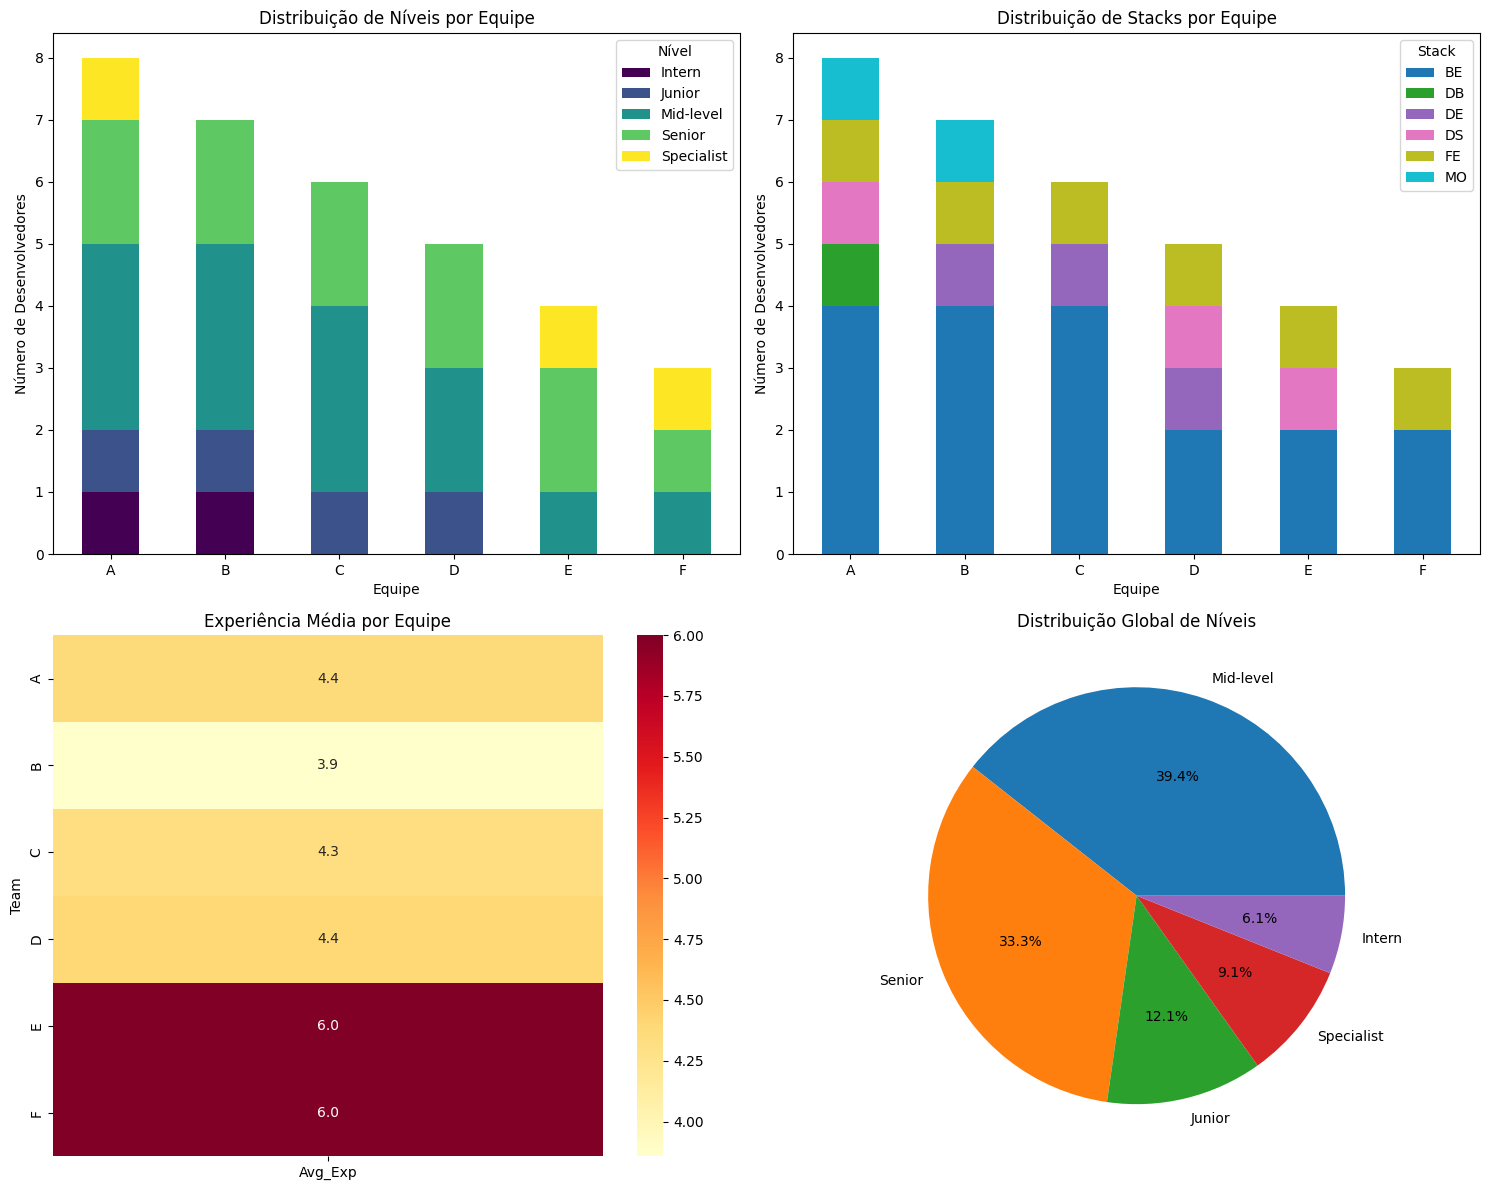

In [ ]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import numpy as np

random.seed(42)
np.random.seed(42)

# Pesos para experiência
experience_weights = {
    'Intern': 0.10,
    'Junior': 0.20,
    'Mid-level': 0.35,
    'Senior': 0.25,
    'Specialist': 0.10
}

experience_levels = list(experience_weights.keys())

# Configuração das equipes
teams_info = [('A', 8), ('B', 7), ('C', 6), ('D', 5), ('E', 4), ('F', 3)]

# Stacks e pesos
stacks = ['FE', 'BE', 'DE', 'DS', 'DB', 'MO']
stack_weights = {
    'BE': 50,
    'FE': 15,
    'DE': 5,
    'DS': 10,
    'DB': 5,
    'MO': 15
}

level_order = {
    'Intern': 0,
    'Junior': 1,
    'Mid-level': 2,
    'Senior': 3,
    'Specialist': 4
}

experience_points = {
    'Intern': 1,
    'Junior': 2,
    'Mid-level': 4,
    'Senior': 6,
    'Specialist': 8
}


def min_max_be_devs(size):
    if size >= 6:
        min_be_devs = 2
        max_be_devs = 4
    else:
        min_be_devs = size // 2
        max_be_devs = min(size - 1, int(size * 0.50))

    return min_be_devs, max_be_devs

def min_max_junior_devs(size):
    if size <= 4:
        min = 0
        max = 0
    else:
        min = 1
        max = 1

    return min, max

def min_max_intern_devs(size):
    if size <= 6:
        min = 0
        max = 0
    else:
        min = 1
        max = 1

    return min, max

def min_max_specialist_devs(size):
    return 0, 1


def min_max_senior_devs(size):
    if size == 3:
        min = 1
        max = 1
    else:
        min = 1
        max = 2

    return min, max


def weighted_choice(weight_dict):
    items = list(weight_dict.keys())
    weights = list(weight_dict.values())

    return random.choices(items, weights=weights, k=1)[0]


def calculate_team_requirements(size):
    """Calcula requisitos ideais para uma equipe baseado no tamanho"""
    (min_be_devs, max_be_devs) = min_max_be_devs(size)
    (min_junior_devs, max_junior_devs) = min_max_junior_devs(size)
    (min_intern_devs, max_intern_devs) = min_max_intern_devs(size)

    requirements = {
        'min_stacks': max(2, min(6, size - 1)),  # Entre 2-6 stacks diferentes
        'max_specialists': 1 if size <= 5 else 2,
        'max_seniors': max(1, size // 3),  # ~33% podem ser seniors
        'max_interns': max_intern_devs,
        'max_juniors': max_junior_devs,
        'min_experience_points': size * 2.5,  # Experiência mínima por equipe
        'ideal_experience_points': size * 4,   # Experiência ideal por equipe
        'min_be_devs': min_be_devs,
        'max_be_devs': max_be_devs,
        'max_de_devs': 1 if size <= 5 else 2,  # DevOps/Engineering
    }

    # Stacks obrigatórias baseadas no tamanho da equipe
    requirements['required_stacks'] = ['BE']  # BE sempre obrigatório

    # Maior ou igual a 3: Adiciona FE
    if size >= 3:
        requirements['required_stacks'].append('FE')  # Frontend essencial

    # Times médios (5+ pessoas): começar diversificação
    if size >= 5:
        requirements['required_stacks'].extend(['DE', 'MO'])  # DevOps + Mobile

    # Times grandes (7+ pessoas): máxima diversidade
    if size >= 7:
        requirements['required_stacks'].extend(['DS', 'DB'])  # Data Science + Database

    return requirements


def generate_balanced_devs(teams_info):
    """Gera desenvolvedores considerando as necessidades de todas as equipes"""
    total_devs = sum(size for _, size in teams_info)

    # Calcular necessidades agregadas de todas as equipes
    total_requirements = {
        'required_stacks': set(),
        'total_specialists_needed': 0,
        'total_seniors_needed': 0,
        'min_experience_needed': 0
    }

    for team_name, size in teams_info:
        req = calculate_team_requirements(size)
        total_requirements['required_stacks'].update(req['required_stacks'])
        total_requirements['total_specialists_needed'] += req['max_specialists']
        total_requirements['total_seniors_needed'] += req['max_seniors']
        total_requirements['min_experience_needed'] += req['min_experience_points']

    devs = []
    counts_level = defaultdict(int)
    counts_stack = defaultdict(int)
    specialist_stacks = set()
    current_experience_total = 0

    # Primeira passagem: garantir stacks essenciais e BE como maioria
    essential_devs = 0

    # Para cada time, garantir pelo menos a quantidade mínima de BE
    total_be_needed = 0
    for team_name, size in teams_info:
        req = calculate_team_requirements(size)
        total_be_needed += req['min_be_devs']

    # Gerar BEs primeiro (maioria garantida)
    be_devs_created = 0
    levels_for_be = ['Senior', 'Mid-level', 'Senior', 'Mid-level', 'Specialist']  # Priorizar experiência para BE

    while be_devs_created < total_be_needed and essential_devs < total_devs:
        level = levels_for_be[be_devs_created % len(levels_for_be)]
        dev = {
            'dev_id': f'Dev{essential_devs + 1}',
            'level': level,
            'stack': 'BE'
        }
        devs.append(dev)
        counts_level[level] += 1
        counts_stack['BE'] += 1
        current_experience_total += experience_points[level]
        essential_devs += 1
        be_devs_created += 1

    # Depois garantir outras stacks essenciais
    other_essential_stacks = total_requirements['required_stacks'] - {'BE'}
    for stack in other_essential_stacks:
        if essential_devs >= total_devs:
            break
        level = 'Mid-level'  # Nível seguro para outras stacks
        dev = {
            'dev_id': f'Dev{essential_devs + 1}',
            'level': level,
            'stack': stack
        }
        devs.append(dev)
        counts_level[level] += 1
        counts_stack[stack] += 1
        current_experience_total += experience_points[level]
        essential_devs += 1

    # Segunda passagem: preencher o restante com balanceamento inteligente
    for i in range(essential_devs + 1, total_devs + 1):
        # Calcular se precisamos de mais experiência
        remaining_devs = total_devs - i + 1
        experience_needed = total_requirements['min_experience_needed'] - current_experience_total
        avg_experience_needed = experience_needed / max(1, remaining_devs)

        # Ajustar pesos baseado na necessidade
        adjusted_weights = experience_weights.copy()

        # Se precisamos de mais experiência, aumentar peso de níveis seniores
        if avg_experience_needed > 3:
            adjusted_weights['Senior'] *= 2
            adjusted_weights['Specialist'] *= 1.5
            adjusted_weights['Mid-level'] *= 1.2
            adjusted_weights['Intern'] *= 0.5
            adjusted_weights['Junior'] *= 0.7

        # Controlar limites máximos
        if counts_level['Intern'] >= total_devs * 0.05:  # Max 5% estagiários
            adjusted_weights.pop('Intern', None)
        if counts_level['Junior'] >= total_devs * 0.20:  # Max 20% juniors
            adjusted_weights.pop('Junior', None)
        if counts_level['Specialist'] >= total_requirements['total_specialists_needed']:
            adjusted_weights.pop('Specialist', None)
        if counts_level['Senior'] >= total_requirements['total_seniors_needed']:
            adjusted_weights['Senior'] *= 0.35

        if not adjusted_weights:
            adjusted_weights = {'Mid-level': 1}

        level = weighted_choice(adjusted_weights)

        # Escolher stack baseado na necessidade e diversidade
        stack_scores = {}
        for stack in stacks:
            base_score = stack_weights[stack]

            # Bônus adicional para BE, se ainda não atingiu a maioria necessária
            if stack == 'BE':
                be_percentage = counts_stack['BE'] / max(1, i - 1)
                if be_percentage < 0.55:  # Se BE está abaixo de 55%
                    base_score *= 5  # Multiplicador alto para priorizar BE
                elif be_percentage < 0.50:  # Se BE está abaixo de 50%
                    base_score *= 10  # Multiplicador muito alto

            # Bonus para stacks com poucos desenvolvedores (exceto BE que tem lógica própria)
            if stack != 'BE' and counts_stack[stack] < total_devs * 0.10:  # Menos de 10%
                base_score *= 1.5

            # Penalty para stacks não-BE com muitos desenvolvedores
            if stack != 'BE' and counts_stack[stack] > total_devs * 0.25:  # Mais de 25%
                base_score *= 0.2

            # Specialists precisam de stacks únicas
            if level == 'Specialist' and stack in specialist_stacks:
                base_score = 0

            stack_scores[stack] = max(1, base_score)

        stack = weighted_choice(stack_scores)

        # Registrar specialist stack
        if level == 'Specialist':
            specialist_stacks.add(stack)

        dev = {
            'dev_id': f'Dev{i}',
            'level': level,
            'stack': stack
        }
        devs.append(dev)
        counts_level[level] += 1
        counts_stack[stack] += 1
        current_experience_total += experience_points[level]

    return pd.DataFrame(devs)

def distribute_devs_to_balanced_teams(df_devs, teams_info):
    """Distribui desenvolvedores para equipes de forma equilibrada e inteligente"""
    teams = []
    dev_pool = df_devs.copy()
    dev_pool['assigned'] = False

    def calculate_team_balance(team_devs):
        """Calcula métricas de balanceamento da equipe"""
        if not team_devs:
            return 0

        levels = [d['level'] for d in team_devs]
        stacks = [d['stack'] for d in team_devs]

        # Pontuação de experiência
        exp_score = sum(experience_points[level] for level in levels)

        # Diversidade de stacks
        stack_diversity = len(set(stacks))

        # Penalizar desequilíbrios
        penalties = 0
        level_counts = Counter(levels)

        # Muitos iniciantes
        if level_counts['Intern'] + level_counts['Junior'] > len(team_devs) * 0.5:
            penalties += 40

        # Muito poucos seniores em times grandes
        if len(team_devs) >= 5 and level_counts['Senior'] + level_counts['Specialist'] == 0:
            penalties += 15

        return exp_score + stack_diversity * 5 - penalties

    def select_best_dev_for_team(team_devs, team_size, available_devs):
        """Seleciona o melhor desenvolvedor para a equipe baseado em múltiplos critérios"""
        if available_devs.empty:
            return None

        requirements = calculate_team_requirements(team_size)
        current_stacks = [d['stack'] for d in team_devs]
        current_levels = [d['level'] for d in team_devs]
        level_counts = Counter(current_levels)
        stack_counts = Counter(current_stacks)

        # Verificar quantos BEs já temos
        current_be_count = stack_counts.get('BE', 0)

        best_dev = None
        best_score = -1000

        for idx, dev in available_devs.iterrows():
            score = 0

            # PRIORIDADE MÁXIMA: Garantir maioria BE (com limite para times pequenos)
            if dev['stack'] == 'BE':
                if current_be_count < requirements['min_be_devs']:
                    score += 1000  # Score altíssimo para BE quando necessário
                elif current_be_count < requirements['max_be_devs']:
                    score += 100   # Score alto para BE adicional (respeitando limite)
                else:
                    score -= 200   # Penalizar BE em excesso (mais forte para times pequenos)
            else:
                # Para não-BE, verificar se BE já está garantido
                if current_be_count < requirements['min_be_devs']:
                    score -= 500  # Penalizar muito não-BE se BE não está garantido
                elif current_be_count >= requirements['max_be_devs']:
                    score += 50   # Bonus para não-BE se BE já atingiu o máximo

            # Pontuação base de experiência
            score += experience_points[dev['level']] * 2

            # Bonus para stacks obrigatórias que ainda não temos
            if dev['stack'] in requirements['required_stacks'] and dev['stack'] not in current_stacks:
                score += 50

            # Bonus para diversidade de stack (mas menor que BE)
            if dev['stack'] not in current_stacks and dev['stack'] != 'BE':
                score += 20

            # Controlar limites por nível
            if dev['level'] == 'Specialist' and level_counts['Specialist'] >= requirements['max_specialists']:
                continue
            if dev['level'] == 'Senior' and level_counts['Senior'] >= requirements['max_seniors']:
                score -= 5
            if dev['level'] == 'Intern' and level_counts['Intern'] >= requirements['max_interns']:
                continue
            if dev['level'] == 'Junior' and level_counts['Junior'] >= requirements['max_juniors']:
                continue

            # Bonus para stacks com alta demanda (menor para não confundir com prioridade BE)
            if dev['stack'] != 'BE':
                score += stack_weights.get(dev['stack'], 1) * 0.05

            # Pequena aleatoriedade para evitar determinismo total
            score += random.uniform(-1, 1)

            if score > best_score:
                best_score = score
                best_dev = idx

        return best_dev

    # Distribuir desenvolvedores para cada equipe
    for team_name, size in sorted(teams_info, key=lambda x: -x[1]):  # Times maiores primeiro
        team_devs = []
        available_devs = dev_pool[dev_pool['assigned'] == False]

        # Selecionar desenvolvedores um a um
        for position in range(size):
            available_devs = dev_pool[dev_pool['assigned'] == False]

            if available_devs.empty:
                break

            best_dev_idx = select_best_dev_for_team(team_devs, size, available_devs)

            if best_dev_idx is None:
                # Fallback: escolher aleatoriamente
                best_dev_idx = random.choice(available_devs.index.tolist())

            chosen_dev = dev_pool.loc[best_dev_idx]
            dev_pool.at[best_dev_idx, 'assigned'] = True

            team_devs.append({
                'name': f"{team_name}_Dev{len(team_devs)+1}",
                'team': team_name,
                'level': chosen_dev['level'],
                'stack': chosen_dev['stack']
            })

        teams.extend(team_devs)

    return pd.DataFrame(teams)

def swap_devs_by_level_and_stack(df_teams, level_name, min_max_func, max_attempts=100):
    """
    Pós-processamento para corrigir excesso de devs de um nível específico (ex: 'Junior' ou 'Intern').
    Troca devs de mesma stack entre equipes, buscando colocar devs do nível numa equipe que aceita
    e retirar de equipes que não respeitam a regra, usando critério de stack para minimizar impacto.
    """
    import pandas as pd

    df = df_teams.copy()

    attempts = 0
    improved = True

    while attempts < max_attempts and improved:
        improved = False

        # Recalcular os grupos para refletir alterações
        groups = df.groupby('team')

        # Times que tem excesso do nível em questão
        teams_excess = []
        for team_name, group in groups:
            size = len(group)
            _, max_level = min_max_func(size)
            count_level = (group['level'] == level_name).sum()
            if count_level > max_level:
                teams_excess.append(team_name)

        # Times que podem receber esse nível (que aceitam pelo menos 1)
        teams_can_receive = []
        for team_name, group in groups:
            size = len(group)
            _, max_level = min_max_func(size)
            count_level = (group['level'] == level_name).sum()
            if count_level < max_level:
                teams_can_receive.append(team_name)

        # Para cada time com excesso, tentar swaps com times que podem receber
        for team_excess in teams_excess:
            team_excess_df = df[df['team'] == team_excess]
            devs_excess_level = team_excess_df[team_excess_df['level'] == level_name]

            # Para cada dev nesse nível no time com excesso
            for idx_excess, dev_excess in devs_excess_level.iterrows():
                swapped = False

                stack = dev_excess['stack']

                for team_receive in teams_can_receive:
                    if team_receive == team_excess:
                        continue

                    team_receive_df = df[df['team'] == team_receive]

                    # Procurar devs de mesma stack que não tem esse nível
                    candidates_to_swap = team_receive_df[
                        (team_receive_df['stack'] == stack) &
                        (team_receive_df['level'] != level_name)
                    ]

                    if candidates_to_swap.empty:
                        continue

                    # Escolhe o primeiro candidato available para troca
                    idx_receive, dev_receive = candidates_to_swap.iloc[0].name, candidates_to_swap.iloc[0]

                    # Verifica se a equipe que vai receber o dev aceitaria mais um do level
                    size_rcv = len(team_receive_df)
                    _, max_level_rcv = min_max_func(size_rcv)
                    count_level_rcv = (team_receive_df['level'] == level_name).sum()

                    if count_level_rcv >= max_level_rcv:
                        continue

                    # Verifica se equipe que vai receber o dev_receive não ultrapassará o limite do nível que ele tem
                    # (para evitar colocar junior/intern em time que não aceita)
                    size_excess = len(team_excess_df)
                    _, max_level_ex = min_max_func(size_excess)
                    count_level_excess = (team_excess_df['level'] == level_name).sum()

                    # Executar a troca dos times
                    df.at[idx_excess, 'team'] = team_receive
                    df.at[idx_receive, 'team'] = team_excess

                    improved = True
                    swapped = True
                    break

                if swapped:
                    break

            if improved:
                break

        attempts += 1

    return df


def balance_interns_and_juniors(df, max_attempts=100):
    # Primeiro corrige Intern
    df = swap_devs_by_level_and_stack(df, 'Intern', min_max_intern_devs, max_attempts=max_attempts)

    # Depois corrige Junior
    df = swap_devs_by_level_and_stack(df, 'Junior', min_max_junior_devs, max_attempts=max_attempts)

    # Depois corrige Specialists
    df = swap_devs_by_level_and_stack(df, 'Specialist', min_max_specialist_devs, max_attempts=max_attempts)

    # Depois corrige Senior
    df = swap_devs_by_level_and_stack(df, 'Senior', min_max_senior_devs, max_attempts=max_attempts)

    def update_names(df):
        """
        Para cada equipe no DataFrame, renumera os devs sequencialmente
        seguindo o padrão: <team>_Dev<sequencia>.
        Garante que nomes fiquem únicos e condizentes com a equipe atual.
        """
        df = df.copy()
        df = df.sort_values(['team', 'level', 'stack'], ascending=[True, True, True]).reset_index(drop=True)
        new_names = []
        counters = {}

        for _, row in df.iterrows():
            team = row['team']

            counters.setdefault(team, 1)

            new_name = f"{team}_Dev{counters[team]}"
            new_names.append(new_name)

            counters[team] += 1

        df['name'] = new_names
        return df

    return update_names(df)

def analyze_team_composition(df_teams):
    """Analisa e exibe estatísticas da composição das equipes"""
    print("=== ANÁLISE DE COMPOSIÇÃO DAS EQUIPES ===\n")

    # Estatísticas por equipe
    for team in sorted(df_teams['team'].unique()):
        team_data = df_teams[df_teams['team'] == team]
        print(f"EQUIPE {team} ({len(team_data)} membros):")

        # Distribuição por nível
        level_dist = team_data['level'].value_counts()
        print(f"  Níveis: {dict(level_dist)}")

        # Distribuição por stack
        stack_dist = team_data['stack'].value_counts()
        print(f"  Stacks: {dict(stack_dist)}")

        # Verificar maioria BE (com lógica especial para times pequenos)
        be_count = stack_dist.get('BE', 0)
        total_team = len(team_data)
        be_percentage = (be_count / total_team) * 100

        if total_team <= 3:
            # Para times pequenos: verificar se respeitou o limite máximo
            is_valid = be_count <= 2
            status = f"✅ DENTRO DO LIMITE (máx 2)" if is_valid else f"❌ EXCEDEU LIMITE (máx 2)"
        else:
            # Para times maiores: verificar maioria
            is_majority = be_count > total_team // 2
            status = "✅ MAIORIA" if is_majority else "❌ NÃO É MAIORIA"

        print(f"  BE: {be_count}/{total_team} ({be_percentage:.1f}%) - {status}")

        # Pontuação de experiência
        exp_score = sum(experience_points[level] for level in team_data['level'])
        avg_exp = exp_score / len(team_data)
        print(f"  Experiência: {exp_score} pontos (média: {avg_exp:.1f})")

        print()

    # Estatísticas globais
    print("=== ESTATÍSTICAS GLOBAIS ===")
    print(f"Total de desenvolvedores: {len(df_teams)}")

    # Verificar se BE é maioria globalmente
    global_be = len(df_teams[df_teams['stack'] == 'BE'])
    global_total = len(df_teams)
    global_be_pct = (global_be / global_total) * 100
    print(f"BE Global: {global_be}/{global_total} ({global_be_pct:.1f}%)")

    print(f"\nDistribuição por nível:")
    for level, count in df_teams['level'].value_counts().items():
        pct = (count / len(df_teams)) * 100
        print(f"  {level}: {count} ({pct:.1f}%)")

    print(f"\nDistribuição por stack:")
    for stack, count in df_teams['stack'].value_counts().items():
        pct = (count / len(df_teams)) * 100
        print(f"  {stack}: {count} ({pct:.1f}%)")

    # Verificar quantas equipes seguem as regras de BE
    teams_following_rules = 0
    total_teams = len(df_teams['team'].unique())

    for team in df_teams['team'].unique():
        team_data = df_teams[df_teams['team'] == team]
        be_count = len(team_data[team_data['stack'] == 'BE'])
        team_size = len(team_data)

        if team_size <= 3:
            # Para times pequenos: máximo 2 BE
            follows_rule = be_count <= 2
        else:
            # Para times maiores: maioria BE
            follows_rule = be_count > team_size // 2

        if follows_rule:
            teams_following_rules += 1

    print(f"\n📊 RESUMO BE:")
    print(f"  Equipes seguindo regras BE: {teams_following_rules}/{total_teams}")
    print(f"  Percentual de sucesso: {(teams_following_rules/total_teams)*100:.1f}%")
    print(f"  Regra: Times ≤3 pessoas = máx 2 BE | Times >3 pessoas = maioria BE")

def create_visualization(df_teams):
    """Cria visualizações da distribuição das equipes"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Distribuição de níveis por equipe
    level_by_team = pd.crosstab(df_teams['team'], df_teams['level'])
    level_by_team.plot(kind='bar', stacked=True, ax=axes[0,0], colormap='viridis')
    axes[0,0].set_title('Distribuição de Níveis por Equipe')
    axes[0,0].set_xlabel('Equipe')
    axes[0,0].set_ylabel('Número de Desenvolvedores')
    axes[0,0].legend(title='Nível')
    axes[0,0].tick_params(axis='x', rotation=0)

    # 2. Distribuição de stacks por equipe
    stack_by_team = pd.crosstab(df_teams['team'], df_teams['stack'])
    stack_by_team.plot(kind='bar', stacked=True, ax=axes[0,1], colormap='tab10')
    axes[0,1].set_title('Distribuição de Stacks por Equipe')
    axes[0,1].set_xlabel('Equipe')
    axes[0,1].set_ylabel('Número de Desenvolvedores')
    axes[0,1].legend(title='Stack')
    axes[0,1].tick_params(axis='x', rotation=0)

    # 3. Heatmap de experiência por equipe
    experience_data = []
    for team in sorted(df_teams['team'].unique()):
        team_data = df_teams[df_teams['team'] == team]
        total_exp = sum(experience_points[level] for level in team_data['level'])
        avg_exp = total_exp / len(team_data)
        experience_data.append([team, len(team_data), total_exp, avg_exp])

    exp_df = pd.DataFrame(experience_data, columns=['Team', 'Size', 'Total_Exp', 'Avg_Exp'])

    # Criar matriz para heatmap
    heatmap_data = exp_df.pivot_table(values='Avg_Exp', index=['Team'], aggfunc='mean')
    sns.heatmap(heatmap_data, annot=True, fmt='.1f', ax=axes[1,0], cmap='YlOrRd')
    axes[1,0].set_title('Experiência Média por Equipe')

    # 4. Distribuição global
    global_dist = df_teams['level'].value_counts()
    axes[1,1].pie(global_dist.values, labels=global_dist.index, autopct='%1.1f%%')
    axes[1,1].set_title('Distribuição Global de Níveis')

    plt.tight_layout()
    plt.show()

# Executar o sistema completo
df_devs = generate_balanced_devs(teams_info)
df_teams_simple = distribute_devs_to_balanced_teams(df_devs, teams_info)
df_teams_balanced = balance_interns_and_juniors(df_teams_simple)

# Exibir resultados
print("\n" + "="*50)
print("EQUIPES FORMADAS:")
print("="*50)
print(df_teams_balanced)

# Análise detalhada
analyze_team_composition(df_teams_balanced)

# Visualizações
create_visualization(df_teams_balanced)

# Salvar resultados em CSV
df_teams_balanced.to_csv('teams_dataset.csv', index=False)